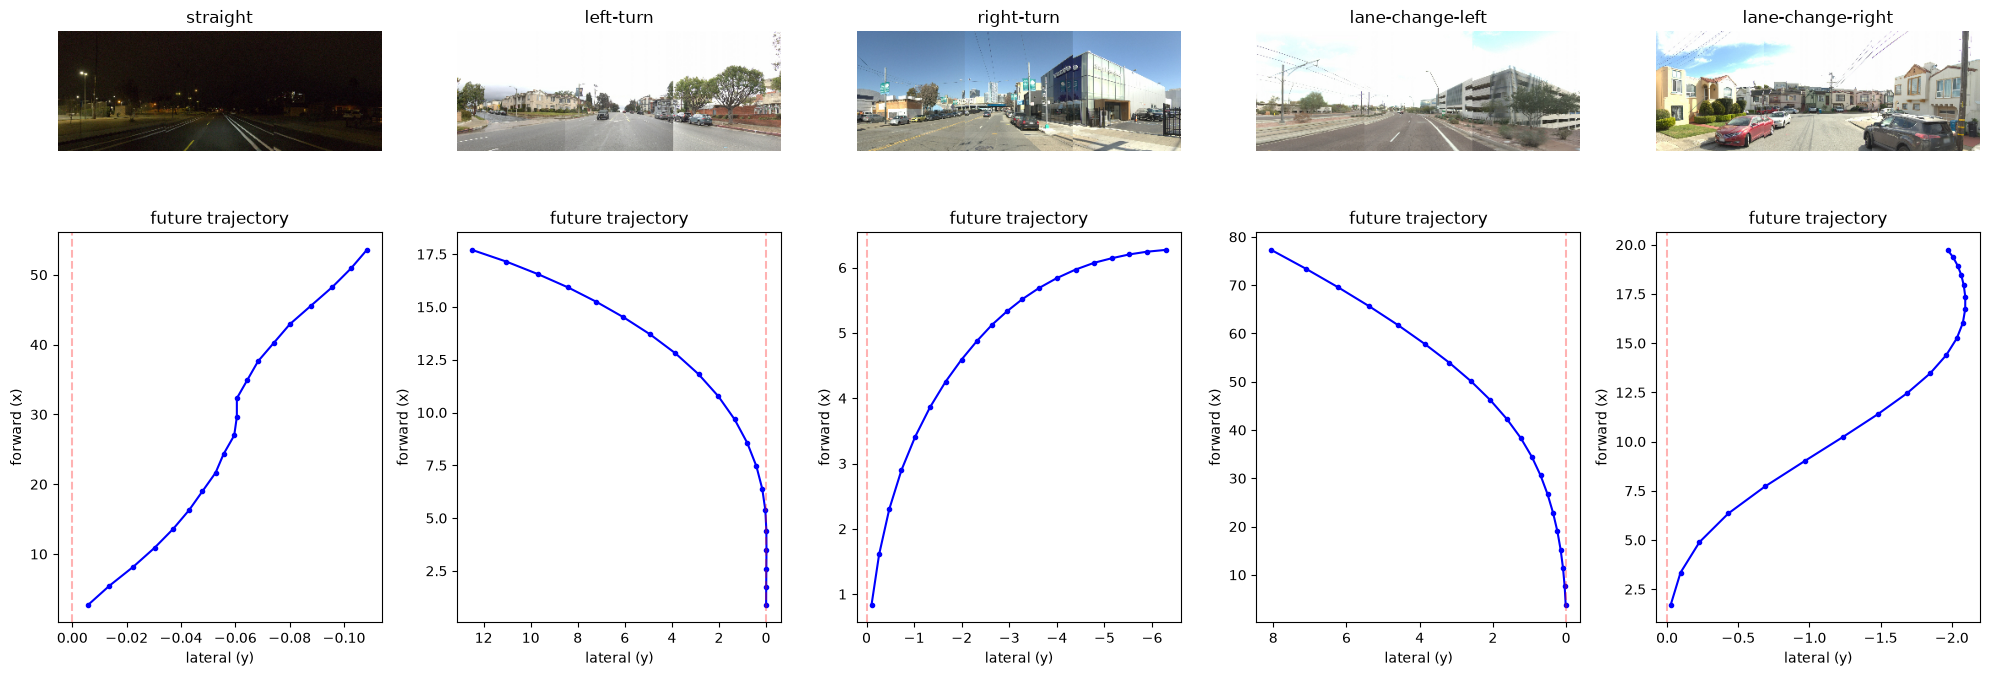

In [7]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from standard_e2e import Modality, TrajectoryComponent

val_dir = '../data/processed/waymo_e2e/val'
files = sorted([f for f in os.listdir(val_dir) if f.endswith('.npz')])

def classify_future_maneuver(xs, ys):
    total_dist = np.sqrt((xs[-1] - xs[0])**2 + (ys[-1] - ys[0])**2)
    if total_dist < 2.0:
        return 'stationary'
    n = len(xs)
    mid = n // 2
    dx1 = xs[mid] - xs[0]
    dy1 = ys[mid] - ys[0]
    dx2 = xs[-1] - xs[mid]
    dy2 = ys[-1] - ys[mid]
    mag1 = np.sqrt(dx1**2 + dy1**2)
    mag2 = np.sqrt(dx2**2 + dy2**2)
    if mag1 < 0.1 or mag2 < 0.1:
        return 'stationary'
    cross = dx1 * dy2 - dy1 * dx2
    dot = dx1 * dx2 + dy1 * dy2
    angle = np.arctan2(cross / (mag1 * mag2), dot / (mag1 * mag2)) * 180 / np.pi
    if dot / (mag1 * mag2) < -0.3:
        return 'left-turn' if ys[-1] > 0 else 'right-turn'
    elif abs(angle) < 8:
        return 'straight'
    elif abs(angle) < 20:
        return 'lane-change-left' if ys[-1] > 0 else 'lane-change-right'
    else:
        return 'left-turn' if ys[-1] > 0 else 'right-turn'

target_classes = ['straight', 'left-turn', 'right-turn', 'lane-change-left', 'lane-change-right']
examples = {}
used_segments = set()

for fname in files:
    if len(examples) == len(target_classes):
        break
    data = np.load(os.path.join(val_dir, fname), allow_pickle=True)
    segment_id = str(data['segment_id'])
    if segment_id in used_segments:
        continue
    modality = data['_modality_data'].item()
    future = modality[Modality.FUTURE_STATES]
    if future.isEmpty:
        continue
    xs = future.get(TrajectoryComponent.X).flatten()
    ys = future.get(TrajectoryComponent.Y).flatten()
    maneuver = classify_future_maneuver(xs, ys)
    if maneuver in target_classes and maneuver not in examples:
        img = modality[Modality.CAMERAS]
        examples[maneuver] = (img, xs, ys)
        used_segments.add(segment_id)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, cls in enumerate(target_classes):
    img, xs, ys = examples[cls]
    # image
    axes[0, i].imshow(np.array(img))
    axes[0, i].set_title(cls)
    axes[0, i].axis('off')
    # trajectory
    axes[1, i].plot(ys, xs, 'b-o', markersize=3)
    axes[1, i].invert_xaxis()
    axes[1, i].set_title('future trajectory')
    axes[1, i].set_xlabel('lateral (y)')
    axes[1, i].set_ylabel('forward (x)')
    axes[1, i].axvline(0, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('maneuver_examples_fixed.png', dpi=150)
plt.show()